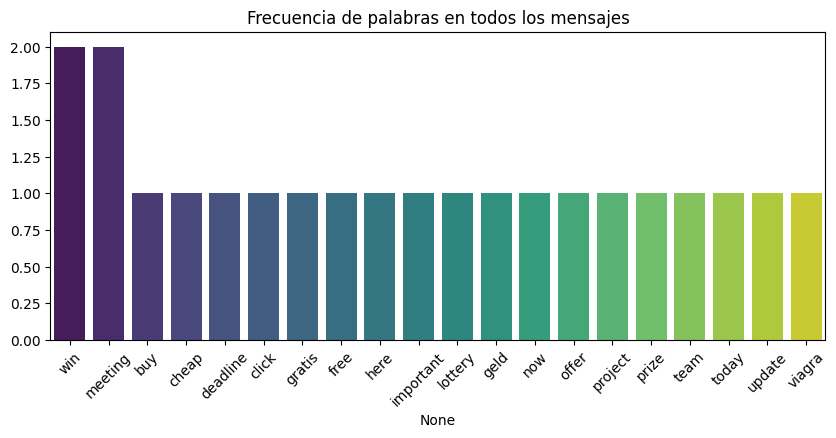


Exactitud (Accuracy): 0.50


,Mensaje Original,Etiqueta Real,Predicción Modelo
0,team meeting,ham,ham
1,lottery win,spam,spam
2,free offer now,spam,ham
3,gratis geld,spam,ham


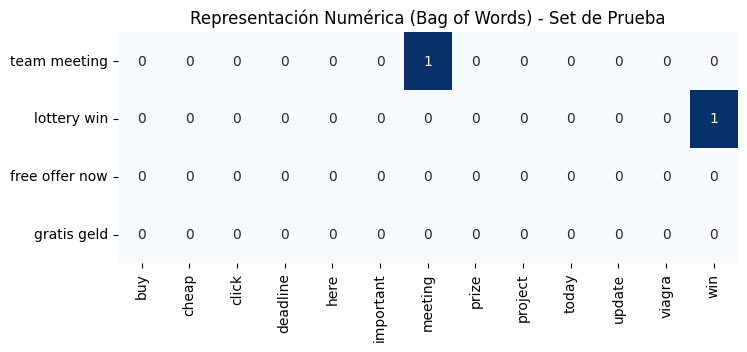

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# --- 1. Preparación de Datos ---
docs = ['gratis geld', 'lottery win', 'meeting today', 'buy viagra', 'project update', 'free offer now',
        'important deadline', 'win prize', 'team meeting', 'click here cheap']
labels = ['spam', 'spam', 'ham', 'spam', 'ham', 'spam', 'ham', 'spam', 'ham', 'spam']

# --- 2. Análisis Visual de Palabras (EDA) ---
vectorizer = CountVectorizer()
X_all_vec = vectorizer.fit_transform(docs)
word_freq = pd.DataFrame(X_all_vec.toarray(), columns=vectorizer.get_feature_names_out())
counts = word_freq.sum().sort_values(ascending=False)

plt.figure(figsize=(10, 4))
sns.barplot(x=counts.index, y=counts.values, hue=counts.index, palette='viridis', legend=False)
plt.title('Frecuencia de palabras en todos los mensajes')
plt.xticks(rotation=45)
plt.show()

# --- 3. Entrenamiento ---
X_train, X_test, y_train, y_test = train_test_split(docs, labels, test_size=0.4, random_state=42)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

nb = MultinomialNB()
nb.fit(X_train_vec, y_train)
y_pred = nb.predict(X_test_vec)

# --- 4. Visualización de Resultados ---
results_df = pd.DataFrame({
    'Mensaje Original': X_test,
    'Etiqueta Real': y_test,
    'Predicción Modelo': y_pred
})

print(f'\nExactitud (Accuracy): {accuracy_score(y_test, y_pred):.2f}')

# Resaltar aciertos y errores visualmente
def highlight_correct(row):
    color = '#d4edda' if row['Etiqueta Real'] == row['Predicción Modelo'] else '#f8d7da'
    return ['background-color: ' + color] * len(row)

display(results_df.style.apply(highlight_correct, axis=1))

# Visualizar la matriz de términos de los mensajes de prueba
plt.figure(figsize=(8, 3))
sns.heatmap(X_test_vec.toarray(), annot=True, cbar=False,
            xticklabels=vectorizer.get_feature_names_out(),
            yticklabels=X_test, cmap='Blues')
plt.title('Representación Numérica (Bag of Words) - Set de Prueba')
plt.show()